<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 164.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 162.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 130.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 141.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [4]:
# Display column names
print(df.columns)

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

In [5]:
# Display data types
print(df.dtypes)

ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

In [6]:
# Display summary information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

In [7]:
# Check dataset shape
print(df.shape)

(65437, 114)

In [8]:
# Generate summary statistics for numerical columns
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [9]:
# Generate summary statistics for categorical columns
df.describe(include='object')

/tmp/ipykernel_305/2803184830.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')

,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,SurveyLength,SurveyEase
count,65437,65437,65437,54806,65437,54466,60784,60488,49237,40897,...,27710,28911,28844,28251,27764,28491,28807,28858,56182,56238
unique,5,8,110,3,1,118,8,418,10853,113,...,5,5,5,954,514,3,9,15,3,3
top,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,...,1-2 times a week,30-60 minutes a day,15-30 minutes a day,None of these,None of these,Hybrid (on-prem and cloud),Traditional public search engine,Software Development,Appropriate in length,Easy
freq,50207,23911,39041,23015,65437,9993,24942,3674,603,6947,...,14426,10951,9341,2364,2834,13230,15813,11918,38767,30071


### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [10]:
# Step 1: Identify missing values
missing_values = df.isnull().sum()

print(missing_values)

# Step 2: View columns with highest missing values
missing_values.sort_values(ascending=False).head(20)

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
Knowledge_9                      37802
Frequency_3                      37727
Knowledge_8                      37679
ProfessionalTech                 37673
Knowledge_7                      37659
Knowledge_6                      37573
Knowledge_5                      37557
Knowledge_2                      37416
Knowledge_4                      37407
Knowledge_3                      37342
dtype: int64

In [11]:
# Handle missing values in key columns
# RemoteWork (categorical → mode)
df['RemoteWork'] = df['RemoteWork'].fillna(
    df['RemoteWork'].mode()[0]
)
# JobSat (numerical → median)
df['JobSat'] = df['JobSat'].fillna(
    df['JobSat'].median()
)
# ConvertedCompYearly (numerical → median)
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(
    df['ConvertedCompYearly'].median()
)
# Verify missing values were handled
df[['RemoteWork', 'JobSat', 'ConvertedCompYearly']].isnull().sum()

RemoteWork             0
JobSat                 0
ConvertedCompYearly    0
dtype: int64

In [12]:
# Remove rows with excessive missing data
df_clean = df.dropna(thresh=50)

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [13]:
# Employment Distribution
df['Employment'].value_counts()

Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking for work;Independent contra

In [14]:
# Job Satisfaction Distribution
df['JobSat'].value_counts().sort_index()

JobSat
0.0       311
1.0       276
2.0       772
3.0      1165
4.0      1130
5.0      1956
6.0      3751
7.0     42690
8.0      7509
9.0      3626
10.0     2251
Name: count, dtype: int64

In [15]:
# Professional Coding Experience Distribution
df['YearsCodePro'].value_counts().head(20)

YearsCodePro
2                   4168
3                   4093
5                   3526
10                  3251
4                   3215
Less than 1 year    2856
6                   2843
1                   2639
8                   2549
7                   2517
12                  1777
15                  1635
20                  1549
9                   1493
11                  1312
13                  1127
14                  1082
25                   998
16                   946
18                   867
Name: count, dtype: int64

Key columns including Employment, JobSat, and YearsCodePro were analyzed using value counts to understand the distribution of survey responses. Full-time employment was the dominant employment category, while job satisfaction scores were concentrated around higher values such as 7 and 8, indicating generally positive satisfaction levels among respondents. The YearsCodePro distribution showed that most respondents had between 1 and 10 years of professional coding experience, reflecting a strong presence of early- and mid-career developers in the dataset

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


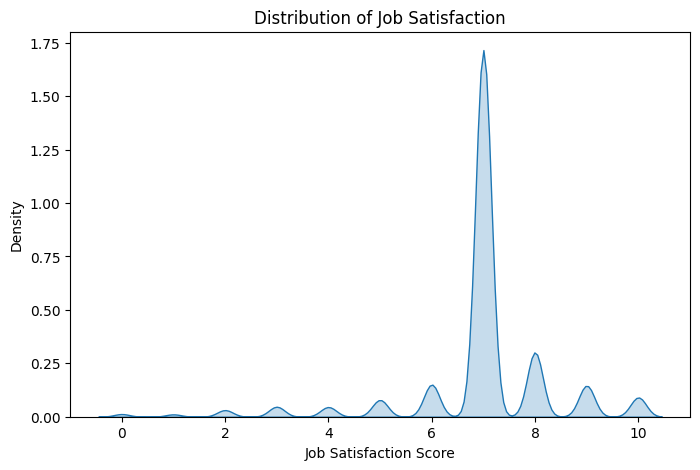

In [16]:
plt.figure(figsize=(8,5))

sns.kdeplot(df['JobSat'], fill=True)

plt.title('Distribution of Job Satisfaction')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Density')

plt.show()

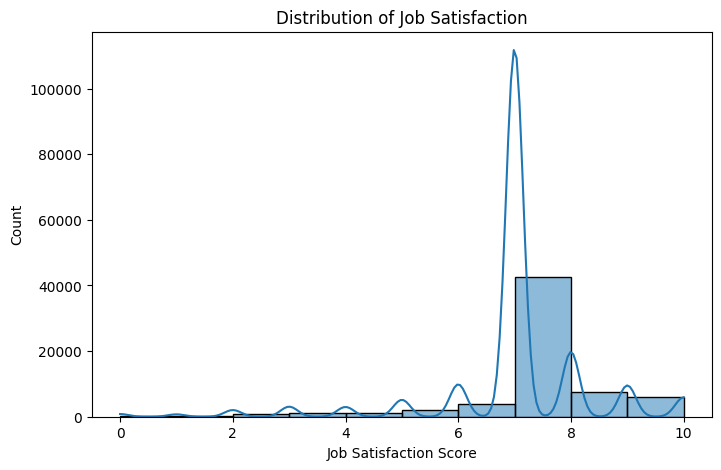

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['JobSat'], kde=True, bins=10)

plt.title('Distribution of Job Satisfaction')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Count')

plt.show()

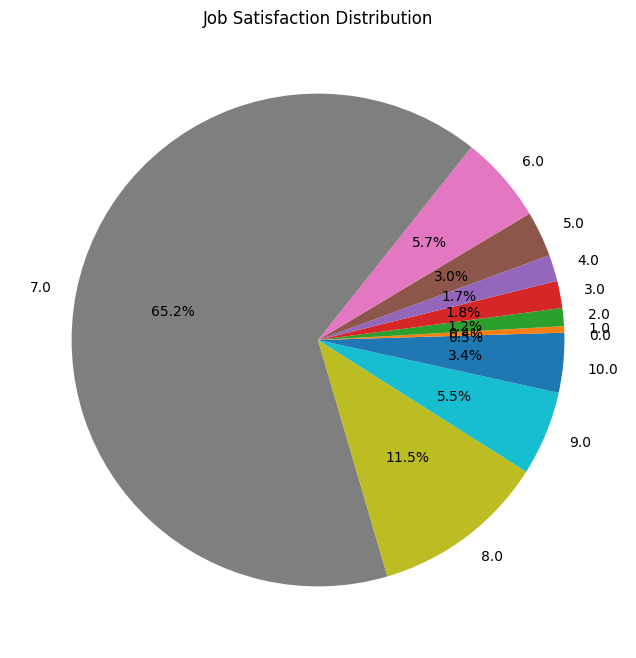

In [18]:
jobsat_counts = df['JobSat'].value_counts().sort_index()

plt.figure(figsize=(8,8))

plt.pie(
    jobsat_counts,
    labels=jobsat_counts.index,
    autopct='%1.1f%%'
)

plt.title('Job Satisfaction Distribution')

plt.show()

The distribution of JobSat was visualized using a KDE plot and histogram. The results show that job satisfaction scores are concentrated around higher values, particularly at 7 and 8. Lower satisfaction scores occur much less frequently, indicating that most respondents report moderate to high levels of job satisfaction. The distribution is slightly skewed toward positive satisfaction levels, suggesting generally favorable workplace experiences among developers.

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


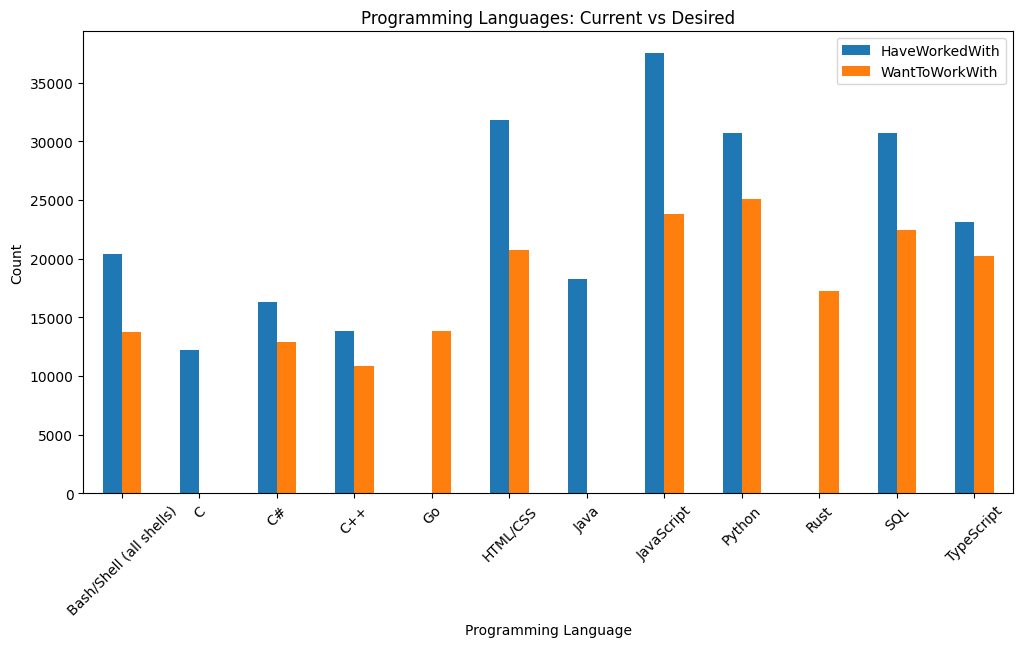

In [19]:
# Step 1: Split language columns. These columns contain multiple values separated by ;.

have_worked = df['LanguageHaveWorkedWith'].dropna().str.split(';')
want_worked = df['LanguageWantToWorkWith'].dropna().str.split(';')

# Step 2: Explode into separate rows
have_exploded = have_worked.explode()
want_exploded = want_worked.explode()

# Step 3: Count language frequencies
have_counts = have_exploded.value_counts().head(10)
want_counts = want_exploded.value_counts().head(10)

# Step 4: Create combined dataframe
language_compare = pd.DataFrame({
    'HaveWorkedWith': have_counts,
    'WantToWorkWith': want_counts
}).fillna(0)

# Step 5: Visualize with grouped bar chart
language_compare.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Programming Languages: Current vs Desired')
plt.xlabel('Programming Language')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

Programming language trends were analyzed by comparing the languages respondents currently use with the languages they want to work with in the future. The analysis showed strong overlap between current and desired technologies, particularly for languages such as JavaScript, Python, and SQL. The grouped bar chart highlighted both the popularity of widely used languages and growing interest in modern programming technologies.

JavaScript and Python dominate both categoriesv - 
SQL remains highly relevant - 
some languages may show higher future interest than current usage - 
modern languages/tools may appear more in “want to work with” results

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


RemoteWork                Hybrid (some remote, some in-person)  In-person  \
Country                                                                     
Canada                                                     970        227   
Germany                                                   3098        647   
India                                                     2290       1088   
United States of America                                  4857       1472   

RemoteWork                Remote  
Country                           
Canada                       907  
Germany                     1202  
India                        853  
United States of America    4766  

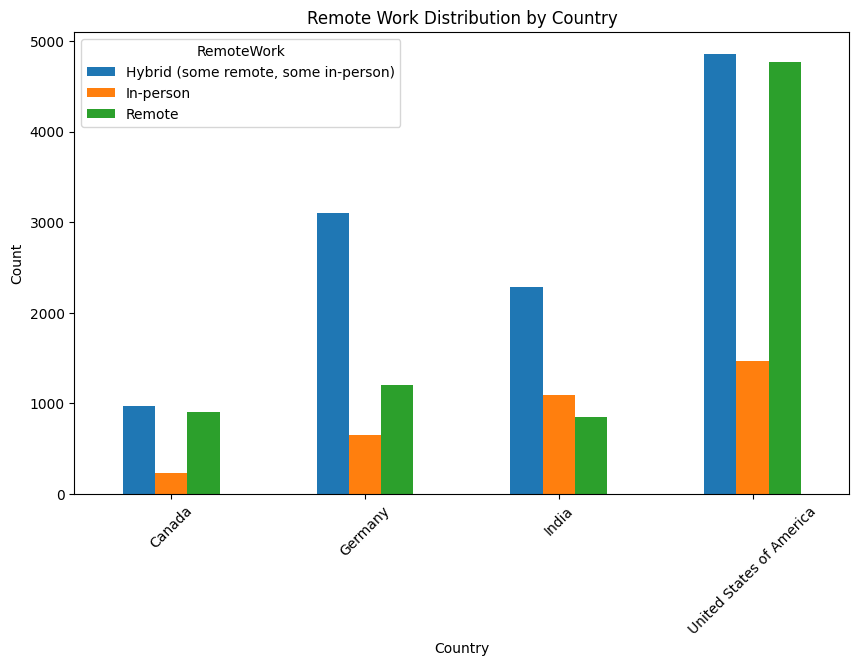

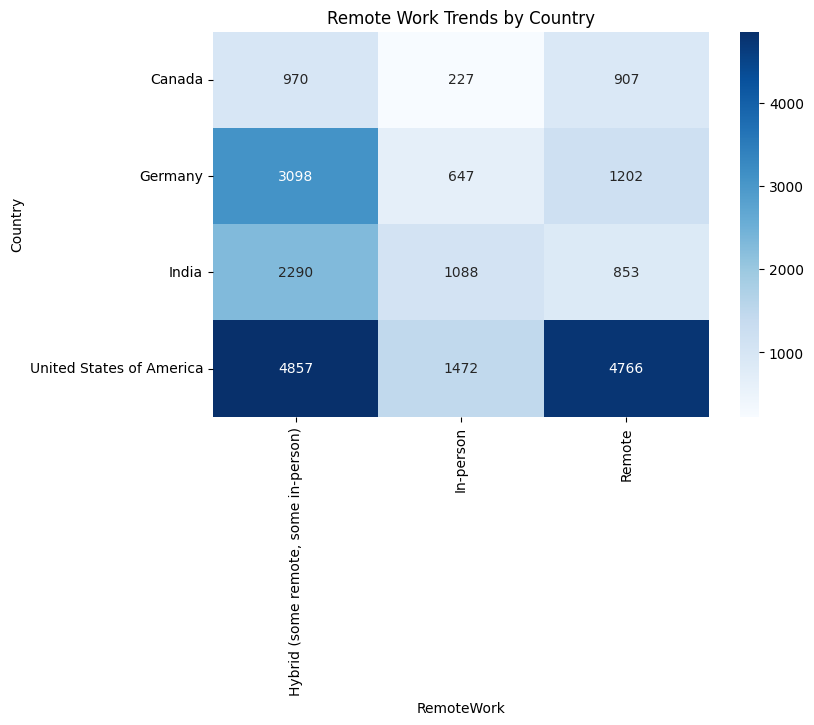

In [20]:
# Step 1: Select regions/countries
selected_countries = [
    'United States of America',
    'India',
    'Germany',
    'Canada'
]

df_region = df[df['Country'].isin(selected_countries)]

# Step 2: Create cross-tabulation
remote_region = pd.crosstab(
    df_region['Country'],
    df_region['RemoteWork']
)

print(remote_region)

# Step 3: Grouped bar chart
remote_region.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Remote Work Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

# Step 4: Heatmap visualization (optional but recommended)
plt.figure(figsize=(8,5))

sns.heatmap(
    remote_region,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Remote Work Trends by Country')

plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [24]:
# Step 1: Clean YearsCodePro. Convert text values into numeric format.

df['YearsCodePro_clean'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 50
})

df['YearsCodePro_clean'] = pd.to_numeric(
    df['YearsCodePro_clean'],
    errors='coerce'
)


In [25]:
# Step 2: Create analysis dataset. Remove rows with missing values.

corr_data = df[['YearsCodePro_clean', 'JobSat']].dropna()


In [26]:
# Step 3: Calculate Pearson correlation
pearson_corr = corr_data['YearsCodePro_clean'].corr(
    corr_data['JobSat'],
    method='pearson'
)

print("Pearson Correlation:", pearson_corr)


Pearson Correlation: 0.07200490076609942

In [30]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 199.5 MB/s eta 0:00:00


In [31]:
# Step 4: Calculate Spearman correlation (optional). Spearman is useful for non-linear or ordinal relationships.
spearman_corr = corr_data['YearsCodePro_clean'].corr(
    corr_data['JobSat'],
    method='spearman'
)

print("Spearman Correlation:", spearman_corr)

Spearman Correlation: 0.09004487989781952

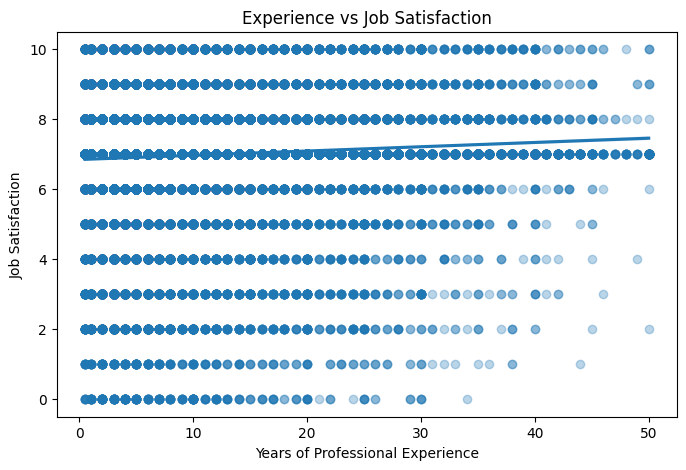

In [28]:
# Optional: Visualize correlation
plt.figure(figsize=(8,5))

sns.regplot(
    data=corr_data,
    x='YearsCodePro_clean',
    y='JobSat',
    scatter_kws={'alpha':0.3}
)

plt.title('Experience vs Job Satisfaction')
plt.xlabel('Years of Professional Experience')
plt.ylabel('Job Satisfaction')

plt.show()

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


EdLevel                                             Associate degree (A.A., A.S., etc.)  \
Employment_clean                                                                          
Employed, full-time                                                                1260   
Employed, part-time                                                                  39   
I prefer not to say                                                                   9   
Independent contractor, freelancer, or self-emp...                                  166   
Not employed, and not looking for work                                               10   
Not employed, but looking for work                                                  100   
Retired                                                                              18   
Student, full-time                                                                  155   
Student, part-time                                                                   36   

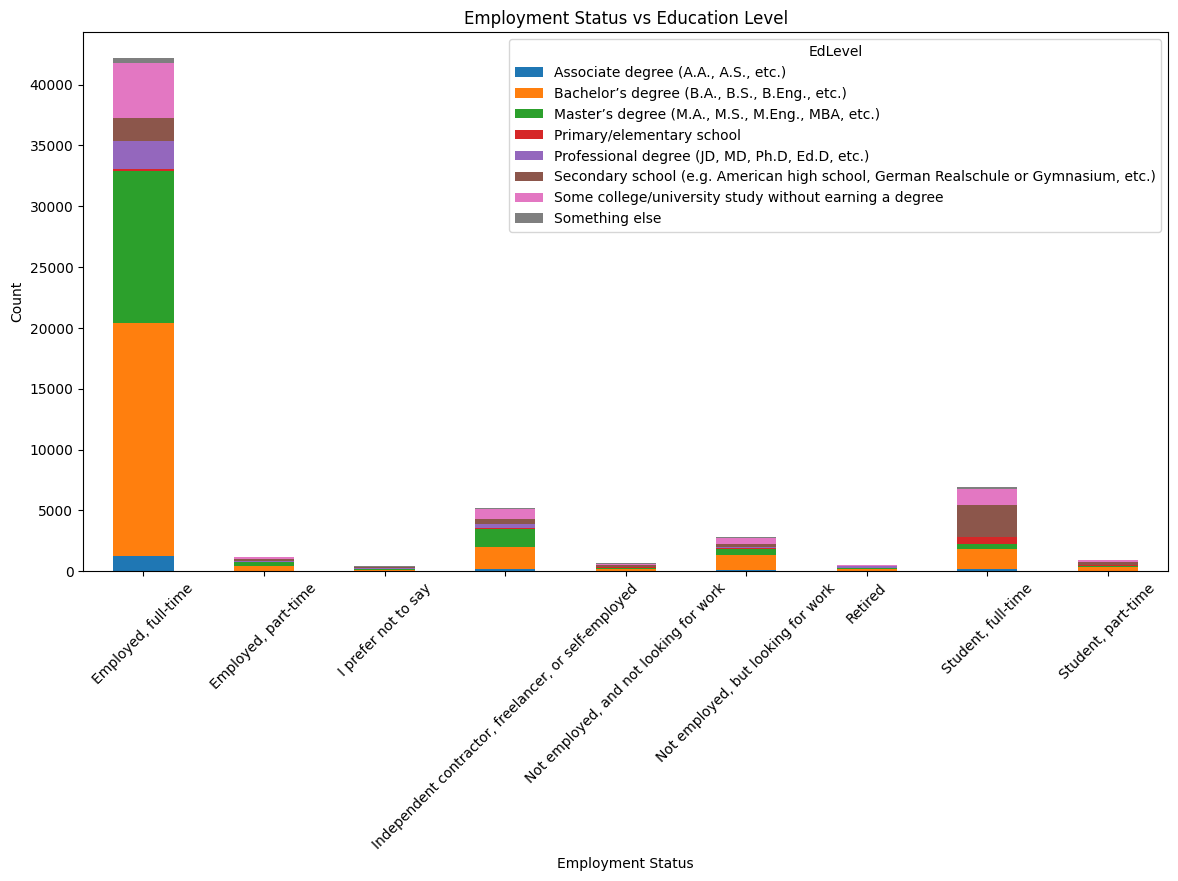

In [32]:
# Step 1: Clean Employment column

# Since Employment contains many combined categories, simplify it first.

df['Employment_clean'] = df['Employment'].str.split(';').str[0]

# Step 2: Create cross-tabulation
employment_education = pd.crosstab(
    df['Employment_clean'],
    df['EdLevel']
)

print(employment_education)

# Step 3: Visualize with stacked bar chart
employment_education.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Employment Status vs Education Level')

plt.xlabel('Employment Status')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [33]:
df.to_csv('cleaned_survey_data.csv', index=False)

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
